# Asset-growth densities by size quintile and oil supply shock tercile

Kernel densities of one-quarter total-asset growth, conditioned jointly on bank size quintile (5 groups) and the tercile of that quarter's oil supply shock (3 groups): 15 densities.

**Shock series.** `data/Kanzig_Oil_Shocks.xlsx` holds Känzig's monthly oil supply series, 1975M01–2025M12. Two columns:

- *Oil supply surprise series*: the high-frequency oil futures price surprise around OPEC announcements. It is the external **instrument** and is zero in months without an announcement.
- *Oil supply news shock*: the structural **shock** identified with that instrument. This is the exogenous shock series and is the one used here.

**Monthly to quarterly.** The news shock is a flow, an innovation that arrives during the month, not a level. The time-consistent quarterly shock is therefore the **sum** of the three monthly shocks in the quarter: if monthly shocks are serially uncorrelated innovations, their sum is the innovation over the quarter, and its variance is the sum of the monthly variances. A quarterly level-type conversion (end-of-quarter value, or point sampling) would discard two-thirds of the shocks. Averaging only rescales the sum by 1/3 and gives identical terciles. The notebook checks the two assumptions this rests on: that the monthly series is close to serially uncorrelated, and that the tercile assignment is robust to weighting earlier months more heavily (a shock in the first month has longer to affect end-of-quarter balance sheets).

**Timing and groups.** The quarter-*t* shock is matched to each bank's asset growth from *t*−1 to *t*, $100 \times (A_t/A_{t-1} - 1)$. Size quintiles are formed each quarter from total assets at *t*−1, as in `size_quintile_distributions.ipynb`. Shock terciles are the 33rd and 67th percentiles of the quarterly shock over the bank sample, 1992Q2–2025Q4. Each tercile therefore contains the same number of quarters.

**Outputs:** `data/processed/oil_shocks_quarterly.csv`; `output/figures/oil_shocks/asset_kde_quintile_by_oil_tercile.pdf`, which has the 15-panel grid on page 1 and an overlay of the three terciles within each quintile on page 2.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FuncFormatter, MaxNLocator

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
PROCESSED = DATA / "processed"
FIGS = ROOT / "output" / "figures" / "oil_shocks"
FIGS.mkdir(parents=True, exist_ok=True)

## Figure style

Same style as the other notebooks. The three shock terciles are ordered, with a neutral middle, so they take a diverging pair: blue for the lowest third, gray for the middle, orange for the highest. The dashed gray line in each grid panel is the quintile's density over all quarters, for reference.

In [2]:
INK = "#1a1a1a"
MUTED = "#6b6b6b"
GRID = "#e3e3e3"
TERCILE_COLORS = {"Low": "#2a78d6", "Middle": "#8a8a8a", "High": "#eb6834"}
REF_COLOR = "#b5b5b5"
WIDTH = 6.5

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "text.color": INK,
    "axes.labelcolor": INK,
    "axes.edgecolor": INK,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "lines.linewidth": 1.4,
    "legend.frameon": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
pct = FuncFormatter(lambda v, _: f"{v:g}%".replace("-", "\u2212"))

## Load the monthly shocks

In [3]:
raw = pd.read_excel(DATA / "Kanzig_Oil_Shocks.xlsx")
raw.columns = ["month", "surprise", "news_shock"]
raw["month"] = pd.PeriodIndex(raw["month"].str.replace("M", "-"), freq="M")
monthly = raw.set_index("month")
assert monthly.index.is_monotonic_increasing and not monthly.index.has_duplicates
assert (monthly.index == pd.period_range(monthly.index[0], monthly.index[-1], freq="M")).all()  # no gaps
print(f"{len(monthly)} months, {monthly.index[0]} to {monthly.index[-1]}")
monthly["news_shock"].describe().round(3).to_frame().T

612 months, 1975-01 to 2025-12


,count,mean,std,min,25%,50%,75%,max
news_shock,612.0,0.0,0.593,-3.209,-0.377,-0.011,0.37,2.047


### Is the monthly shock close to serially uncorrelated?

Summing is the right aggregation for an innovation series. If the monthly shocks were strongly autocorrelated, the quarterly sum would mix in predictable components. The check below uses sample autocorrelations at lags 1–6 against the approximate 95% band $\pm 1.96/\sqrt{T}$, and a Ljung–Box test at 6 and 12 lags.

In [4]:
from scipy import stats

x = monthly["news_shock"].to_numpy()
T = len(x)
xc = x - x.mean()
acf = np.array([np.sum(xc[k:] * xc[:-k]) / np.sum(xc ** 2) for k in range(1, 13)])
band = 1.96 / np.sqrt(T)
display(pd.DataFrame({"lag": range(1, 7), "autocorrelation": acf[:6].round(3),
                      "outside ±1.96/√T": np.abs(acf[:6]) > band}).set_index("lag").T)
for m in (6, 12):
    q = T * (T + 2) * np.sum(acf[:m] ** 2 / (T - np.arange(1, m + 1)))
    print(f"Ljung–Box Q({m}) = {q:.2f}, p = {stats.chi2.sf(q, m):.3f}")

lag,1,2,3,4,5,6
autocorrelation,-0.001,0.011,-0.018,-0.009,-0.029,0.021
outside ±1.96/√T,False,False,False,False,False,False


Ljung–Box Q(6) = 1.14, p = 0.980
Ljung–Box Q(12) = 2.49, p = 0.998


## Aggregate to quarters

Main series: the plain within-quarter sum. Robustness series: a timing-weighted sum with weights 3/2, 1, 1/2 on months 1–3 (proportional to the months each shock has to act before the quarter ends, normalized to sum to 3 so the scale matches the plain sum).

In [5]:
q = monthly.copy()
q["quarter"] = q.index.asfreq("Q")
q["month_in_q"] = (q.index.month - 1) % 3 + 1
q["w"] = q["month_in_q"].map({1: 1.5, 2: 1.0, 3: 0.5})
complete = q.groupby("quarter").size() == 3
quarterly = pd.DataFrame({
    "oil_news_shock": q.groupby("quarter")["news_shock"].sum(),
    "oil_news_shock_timing_wtd": q.assign(wx=q["w"] * q["news_shock"]).groupby("quarter")["wx"].sum(),
    "oil_surprise": q.groupby("quarter")["surprise"].sum(),
}).loc[complete]
quarterly.index.name = "quarter"
quarterly.to_csv(PROCESSED / "oil_shocks_quarterly.csv")
print(f"{len(quarterly)} complete quarters, {quarterly.index[0]} to {quarterly.index[-1]}; "
      "wrote data/processed/oil_shocks_quarterly.csv")
quarterly.describe().round(3)

204 complete quarters, 1975Q1 to 2025Q4; wrote data/processed/oil_shocks_quarterly.csv


,oil_news_shock,oil_news_shock_timing_wtd,oil_surprise
count,204.000,204.000,204.000
mean,0.000,0.029,-0.000
std,1.069,1.145,2.510
min,-5.060,-6.500,-9.806
25%,-0.645,-0.539,-0.253
50%,-0.008,0.079,0.000
75%,0.630,0.631,0.673
max,3.482,3.709,9.903


## Bank asset growth and size quintiles

The construction matches `size_quintile_distributions.ipynb`: insured U.S. branches of foreign banks (class `OI`) are dropped, each bank is matched to its own record one quarter earlier, and quintiles are ranked on assets at *t*−1 among banks observed in both quarters.

In [6]:
panel = pd.read_csv(PROCESSED / "bank_quarter_panel.csv", usecols=["CERT", "REPDTE", "BKCLASS", "ASSET"])
panel = panel.loc[(panel["BKCLASS"] != "OI") & (panel["ASSET"] > 0)].drop(columns="BKCLASS")
panel["date"] = pd.to_datetime(panel["REPDTE"].astype(str), format="%Y%m%d")

lag = panel[["CERT", "date", "ASSET"]].assign(date=lambda d: d["date"] + pd.offsets.QuarterEnd(1))
chg = panel.merge(lag.rename(columns={"ASSET": "ASSET_lag"}), on=["CERT", "date"], how="inner")
chg["assets_chg"] = (chg["ASSET"] / chg["ASSET_lag"] - 1) * 100
size_pct = chg.groupby("date")["ASSET_lag"].rank(pct=True, method="first")
chg["quintile"] = np.ceil(size_pct * 5).clip(1, 5).astype(int)
chg["quarter"] = chg["date"].dt.to_period("Q")
print(f"{len(chg):,} bank-quarters with a one-quarter asset change, {chg['quarter'].min()} to {chg['quarter'].max()}")

1,110,723 bank-quarters with a one-quarter asset change, 1992Q2 to 2026Q2


## Shock terciles

Cutoffs are the 33rd and 67th percentiles of the quarterly shock over the quarters with bank data (1992Q2–2025Q4). Bank-quarters after 2025Q4 have no shock and are dropped. The table compares tercile assignment under the plain and timing-weighted sums.

In [7]:
TERCILES = ["Low", "Middle", "High"]
sample_q = quarterly.loc[chg["quarter"].min():chg["quarter"].max()].copy()


def terciles(s):
    cuts = s.quantile([1 / 3, 2 / 3]).to_numpy()
    return pd.cut(s, [-np.inf, *cuts, np.inf], labels=TERCILES), cuts


sample_q["tercile"], cuts = terciles(sample_q["oil_news_shock"])
sample_q["tercile_wtd"], _ = terciles(sample_q["oil_news_shock_timing_wtd"])
print(f"{len(sample_q)} quarters, {sample_q.index[0]} to {sample_q.index[-1]}; "
      f"cutoffs: {cuts[0]:.3f} and {cuts[1]:.3f}")
display(sample_q["tercile"].value_counts().reindex(TERCILES).rename("quarters").to_frame().T)
agree = (sample_q["tercile"] == sample_q["tercile_wtd"]).mean()
print(f"tercile agreement, plain vs timing-weighted sum: {agree:.1%} of quarters; "
      f"correlation of the two series: {sample_q['oil_news_shock'].corr(sample_q['oil_news_shock_timing_wtd']):.3f}")
pd.crosstab(sample_q["tercile"], sample_q["tercile_wtd"], rownames=["plain sum"], colnames=["timing-weighted"])

135 quarters, 1992Q2 to 2025Q4; cutoffs: -0.403 and 0.322


tercile,Low,Middle,High
quarters,45,45,45


tercile agreement, plain vs timing-weighted sum: 73.3% of quarters; correlation of the two series: 0.928


timing-weighted,Low,Middle,High
plain sum,,,
Low,35,10,0
Middle,10,27,8
High,0,8,37


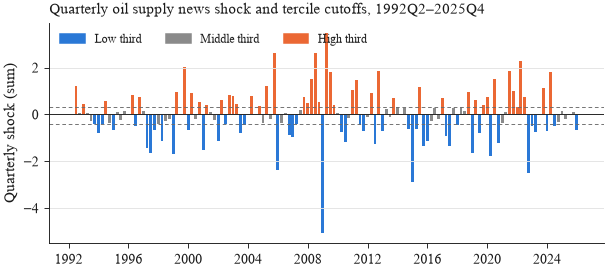

bank-quarters per cell:


tercile,Low,Middle,High
quintile,,,
1,72331,75405,72651
2,72351,75422,72672
3,72350,75420,72667
4,72351,75422,72672
5,72368,75443,72688


In [8]:
fig, ax = plt.subplots(figsize=(WIDTH, 2.6))
x = sample_q.index.to_timestamp(how="end")
colors = sample_q["tercile"].map(TERCILE_COLORS)
ax.bar(x, sample_q["oil_news_shock"], width=70, color=colors, lw=0)
for c in cuts:
    ax.axhline(c, color=MUTED, lw=0.6, ls=(0, (4, 3)))
ax.axhline(0, color=INK, lw=0.6)
ax.set_ylabel("Quarterly shock (sum)")
ax.grid(False, axis="x")
handles = [plt.Rectangle((0, 0), 1, 1, color=TERCILE_COLORS[t]) for t in TERCILES]
ax.legend(handles, [f"{t} third" for t in TERCILES], loc="upper left", ncols=3, fontsize=8)
ax.set_title("Quarterly oil supply news shock and tercile cutoffs, 1992Q2\u20132025Q4", loc="left", fontsize=10)
fig.savefig(FIGS / "oil_shock_quarterly.png")
title = ax.get_title(loc="left")
ax.set_title("", loc="left")
fig.savefig(FIGS / "oil_shock_quarterly_bare.pdf")  # caption-ready copy for LaTeX
ax.set_title(title, loc="left")
plt.show()

chg = chg.merge(sample_q[["tercile"]], left_on="quarter", right_index=True, how="inner")
counts = chg.pivot_table(index="quintile", columns="tercile", values="CERT", aggfunc="size", observed=False)
print("bank-quarters per cell:")
counts

## Kernel densities

These use the same estimator as `size_quintile_distributions.ipynb`: a Gaussian kernel with Silverman's rule-of-thumb bandwidth, computed on a fine grid by linear binning followed by convolution with the kernel. Each cell gets its own bandwidth. All panels share the horizontal range, which is the pooled 1st–99th percentile of asset growth. Observations outside that range still count in the denominator, so each curve integrates to the share of its cell inside the window.

In [9]:
def kde(x, lo, hi, n_grid=2048):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    sd = x.std()
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    spread = min(sd, iqr / 1.34) if iqr > 0 else sd
    h = 0.9 * spread * n ** -0.2
    dx = (hi - lo) / (n_grid - 1)
    pad = int(np.ceil(4 * h / dx))
    centers = lo + dx * np.arange(-pad, n_grid + pad)
    counts, _ = np.histogram(x, bins=np.append(centers - dx / 2, centers[-1] + dx / 2))
    offsets = dx * np.arange(-pad, pad + 1)
    kernel = np.exp(-0.5 * (offsets / h) ** 2)
    kernel /= kernel.sum() * dx
    dens = np.convolve(counts, kernel, mode="same") / n
    return centers[pad:pad + n_grid], dens[pad:pad + n_grid]


LO, HI = np.round(chg["assets_chg"].quantile([0.01, 0.99]).to_numpy(), 1)
QUINTILES = [1, 2, 3, 4, 5]
Q_LABELS = {1: "Q1 (smallest 20%)", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Q5 (largest 20%)"}
dens = {(qi, t): kde(chg.loc[(chg["quintile"] == qi) & (chg["tercile"] == t), "assets_chg"], LO, HI)
        for qi in QUINTILES for t in TERCILES}
ref = {qi: kde(chg.loc[chg["quintile"] == qi, "assets_chg"], LO, HI) for qi in QUINTILES}
medians = chg.groupby(["quintile", "tercile"], observed=False)["assets_chg"].median().unstack()
print(f"horizontal range: {LO}% to {HI}%")
print("median one-quarter asset growth (%):")
medians.round(2)

horizontal range: -10.3% to 32.6%
median one-quarter asset growth (%):


tercile,Low,Middle,High
quintile,,,
1,1.07,0.89,1.06
2,1.18,1.05,1.16
3,1.23,1.10,1.22
4,1.25,1.16,1.25
5,1.38,1.27,1.29


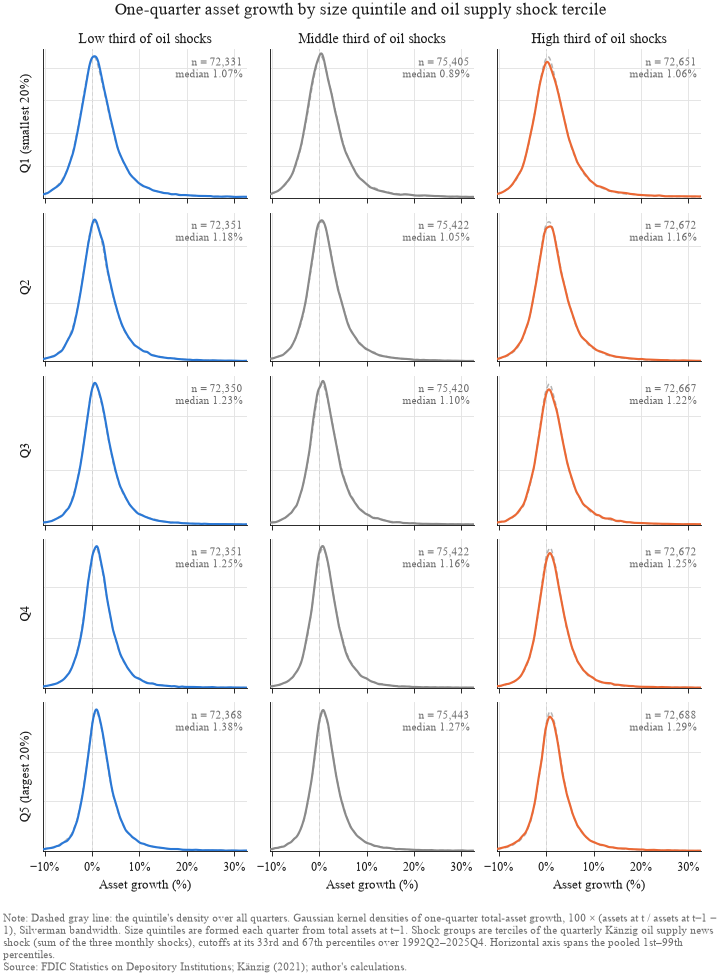

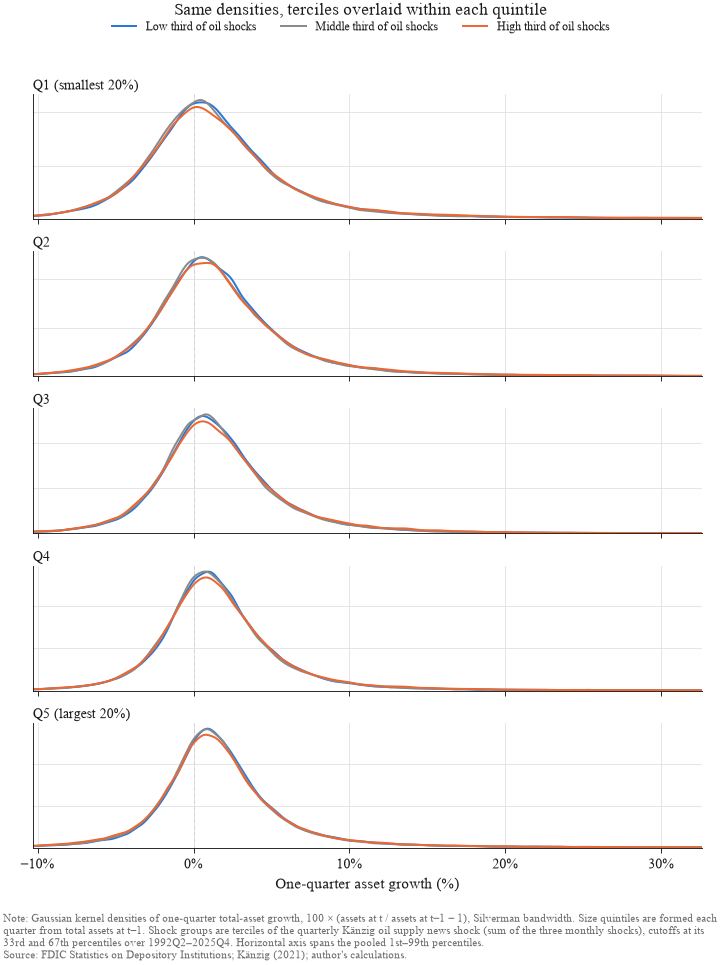

wrote output\figures\oil_shocks\asset_kde_quintile_by_oil_tercile.pdf (2 pages) and caption-ready _bare.pdf copies


In [10]:
NOTE = ("Gaussian kernel densities of one-quarter total-asset growth, 100 \u00d7 (assets at t / assets at t\u22121 \u2212 1), "
        "Silverman bandwidth. Size quintiles are formed each quarter from total assets at t\u22121. Shock groups are terciles "
        "of the quarterly K\u00e4nzig oil supply news shock (sum of the three monthly shocks), cutoffs at its 33rd and "
        "67th percentiles over 1992Q2\u20132025Q4. Horizontal axis spans the pooled 1st\u201399th percentiles.\n"
        "Source: FDIC Statistics on Depository Institutions; K\u00e4nzig (2021); author's calculations.")


def style(ax):
    ax.set_xlim(LO, HI)
    ax.set_ylim(0, None)
    ax.xaxis.set_major_formatter(pct)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.axvline(0, color=INK, lw=0.6, ls=(0, (4, 3)), zorder=1)
    ax.grid(True, axis="x", color=GRID, lw=0.6)
    ax.set_yticklabels([])
    ax.tick_params(axis="y", length=0)


def grid_figure():
    fig, axes = plt.subplots(5, 3, figsize=(WIDTH, 8.4), sharex=True, sharey="row")
    for r, qi in enumerate(QUINTILES):
        for c, t in enumerate(TERCILES):
            ax = axes[r, c]
            ax.plot(*ref[qi], color=REF_COLOR, lw=1.0, ls=(0, (3, 2)), zorder=2)
            ax.plot(*dens[(qi, t)], color=TERCILE_COLORS[t], lw=1.4, zorder=3)
            style(ax)
            ax.text(0.98, 0.95, f"n = {counts.loc[qi, t]:,}\nmedian {medians.loc[qi, t]:.2f}%".replace("-", "\u2212"),
                    transform=ax.transAxes, ha="right", va="top", fontsize=7, color=MUTED)
            if r == 0:
                ax.set_title(f"{t} third of oil shocks", fontsize=9, pad=4)
            if c == 0:
                ax.set_ylabel(Q_LABELS[qi], fontsize=8.5)
            ax.tick_params(axis="x", labelsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("Asset growth (%)", fontsize=8.5)
    fig.suptitle("One-quarter asset growth by size quintile and oil supply shock tercile", fontsize=11, gid="title")
    fig.tight_layout(h_pad=0.6, w_pad=0.6)
    fig.text(0.0, -0.005, "Note: Dashed gray line: the quintile's density over all quarters. " + NOTE,
             ha="left", va="top", fontsize=7.5, color=MUTED, wrap=True, gid="note")
    return fig


def overlay_figure():
    fig, axes = plt.subplots(5, 1, figsize=(WIDTH, 8.4), sharex=True)
    for ax, qi in zip(axes, QUINTILES):
        for t in TERCILES:
            ax.plot(*dens[(qi, t)], color=TERCILE_COLORS[t], lw=1.3, label=f"{t} third of oil shocks")
        style(ax)
        ax.set_title(Q_LABELS[qi], loc="left", fontsize=9, pad=3)
    axes[-1].set_xlabel("One-quarter asset growth (%)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.suptitle("Same densities, terciles overlaid within each quintile", fontsize=11, gid="title")
    fig.tight_layout(h_pad=0.8, rect=(0, 0, 1, 0.95))
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.935), ncols=3, fontsize=8)
    fig.text(0.0, -0.005, "Note: " + NOTE, ha="left", va="top", fontsize=7.5, color=MUTED, wrap=True, gid="note")
    return fig


out = FIGS / "asset_kde_quintile_by_oil_tercile.pdf"
with PdfPages(out) as pdf:
    for make in (grid_figure, overlay_figure):
        fig = make()
        pdf.savefig(fig)
        name = f"asset_kde_{make.__name__.replace('_figure', '')}"
        fig.savefig(FIGS / f"{name}.png")
        # Caption-ready copy for LaTeX: no in-figure title or note
        extras = [t for t in [*fig.texts, fig._suptitle] if t is not None and t.get_gid() in ("note", "title")]
        for t in extras:
            t.set_visible(False)
        fig.savefig(FIGS / f"{name}_bare.pdf")
        for t in extras:
            t.set_visible(True)
        plt.show()
print(f"wrote {out.relative_to(ROOT)} (2 pages) and caption-ready _bare.pdf copies")

## Summary table

Median, interquartile range and 10th–90th percentile range of one-quarter asset growth in each of the 15 cells. Written to `output/tables/oil_tercile_asset_summary.tex` (a `tabular` only, for `\input` inside a `table` environment) and `.csv`.

In [11]:
TABLES = ROOT / "output" / "tables"
g = chg.groupby(["quintile", "tercile"], observed=False)["assets_chg"]
qs = g.quantile([0.10, 0.25, 0.50, 0.75, 0.90]).unstack()
summary = pd.DataFrame({"median": qs[0.50], "iqr": qs[0.75] - qs[0.25], "p90_p10": qs[0.90] - qs[0.10],
                        "n": g.size()})
summary.to_csv(TABLES / "oil_tercile_asset_summary.csv")

wide = summary[["median", "iqr", "p90_p10"]].unstack("tercile")
cell = lambda v: f"{v:.2f}".replace("-", "$-$")
lines = [rf"Q{qi} & " + " & ".join(cell(wide.loc[qi, (s, t)]) for s in ("median", "iqr", "p90_p10") for t in TERCILES)
         + r" \\" for qi in QUINTILES]
tex = (r"\begin{tabular}{@{}lccccccccc@{}}" "\n" r"\toprule" "\n"
       r" & \multicolumn{3}{c}{Median} & \multicolumn{3}{c}{IQR} & \multicolumn{3}{c}{90th$-$10th} \\" "\n"
       r"\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(l){8-10}" "\n"
       r"Size quintile & Low & Mid & High & Low & Mid & High & Low & Mid & High \\" "\n" r"\midrule" "\n"
       + "\n".join(lines) + "\n" r"\bottomrule" "\n" r"\end{tabular}" "\n")
(TABLES / "oil_tercile_asset_summary.tex").write_text(tex, encoding="utf-8")
print("wrote output/tables/oil_tercile_asset_summary.tex and .csv")
wide.round(2)

wrote output/tables/oil_tercile_asset_summary.tex and .csv


median                iqr              p90_p10              
tercile     Low Middle  High   Low Middle  High     Low Middle   High
quintile                                                             
1          1.07   0.89  1.06  5.39   5.38  5.68   12.66  12.46  13.62
2          1.18   1.05  1.16  4.76   4.74  4.98   10.50  10.51  11.26
3          1.23   1.10  1.22  4.44   4.39  4.66    9.68   9.66  10.36
4          1.25   1.16  1.25  4.11   4.08  4.32    9.06   9.08   9.59
5          1.38   1.27  1.29  4.14   4.12  4.30    9.65   9.53  10.02